# Bt / Ip comparison: SELEC2007 (2008) and SELEC2024 (tc26)

Loads `Bt` and `Ip` for time-slices marked selected by `SELEC2007` (2008 dataset) and `SELEC2024` (tc26 dataset).

Both flags are stored in the SimDB manifest as `dbvariable.SELEC2007` / `dbvariable.SELEC2024` metadata.

`Bt`/`Ip` and the selection flags are both read entirely from the SimDB metadata dict (`Simulation.meta_dict()`) — no HDF5/IDS file access is needed.

`Database.query_meta` compares array-valued metadata with `np.any(value == compare)` for the default `EQ`
modifier, so `dbvariable.SELEC2007=1` matches any simulation whose SELEC array contains a 1.

In [ ]:
import numpy as np

import _simdb_common as sc

db = sc.get_db()

sims_2008 = sc.query_selected(db, "2008", "SELEC2007")
sims_tc26 = sc.query_selected(db, "tc26", "SELEC2024")

print(f"2008 pulses with a SELEC2007-selected slice: {len(sims_2008)}")
print(f"tc26 pulses with a SELEC2024-selected slice: {len(sims_tc26)}")

For each matched simulation: read the `SELEC` array and the `Bt`/`Ip` values straight out of the SimDB metadata dict (no IDS access at all), then mask to the selected slices.

In [ ]:
def load_selected_bt_ip(sims, selec_key: str):
    """Return concatenated Bt, Ip, machine arrays over every selected slice across all given simulations."""
    bt_all, ip_all, machine_all = [], [], []
    total = len(sims)
    for i, sim in enumerate(sims, start=1):
        if i % 20 == 0 or i == total:
            print(f"\r  {i}/{total} pulses ({sim.alias})".ljust(80), end="", flush=True)

        md = sim.meta_dict()
        machine = md.get("machine", "")
        selec = sc.temp(md, selec_key, n=0)
        n = len(selec)
        if n == 0:
            continue
        bt = sc.path(md, "global_quantities", "b0", "value", n=n)
        ip = sc.path(md, "global_quantities", "ip", "value", n=n)

        n_slices = min(len(selec), len(bt), len(ip))
        selected = selec[:n_slices] == 1
        bt_all.append(bt[:n_slices][selected])
        ip_all.append(ip[:n_slices][selected])
        machine_all.append(np.full(selected.sum(), machine, dtype=object))
    print()

    if not bt_all:
        return np.array([]), np.array([]), np.array([], dtype=object)
    return np.concatenate(bt_all), np.concatenate(ip_all), np.concatenate(machine_all)


print("2008 / SELEC2007:")
bt_2008, ip_2008, machine_2008 = load_selected_bt_ip(sims_2008, "SELEC2007")
print("tc26 / SELEC2024:")
bt_tc26, ip_tc26, machine_tc26 = load_selected_bt_ip(sims_tc26, "SELEC2024")

print(f"2008 selected slices: {len(bt_2008)}")
print(f"tc26 selected slices: {len(bt_tc26)}")

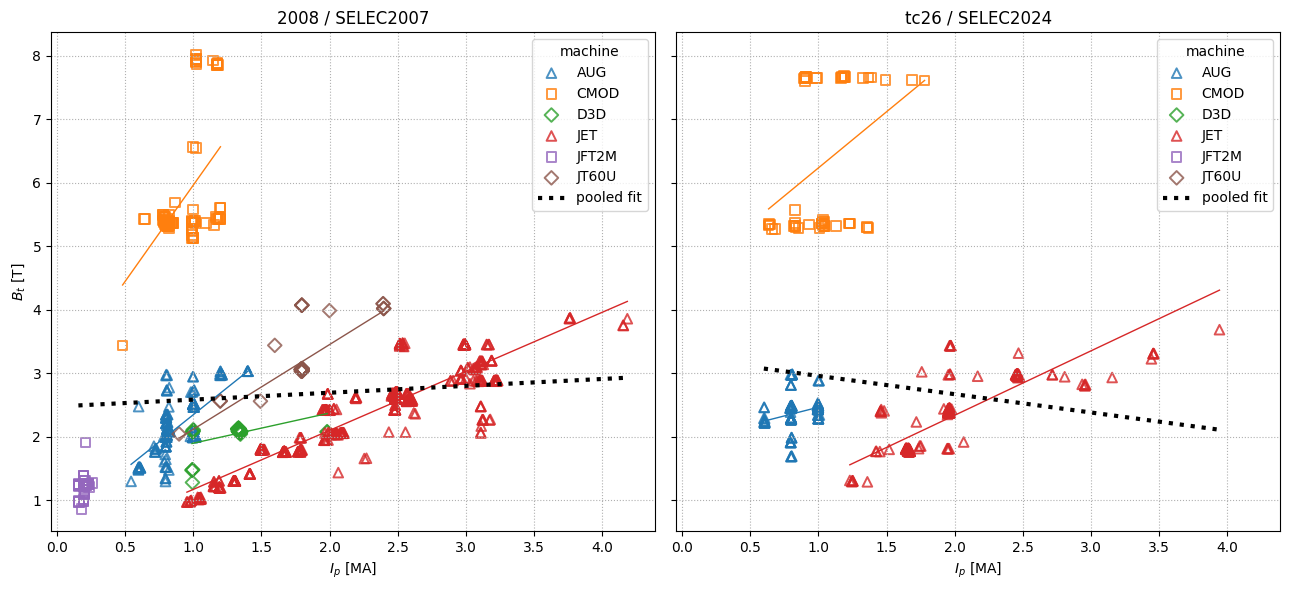

In [88]:
import itertools

import matplotlib.pyplot as plt

machines = sorted(set(machine_2008) | set(machine_tc26))
colors = dict(zip(machines, plt.cm.tab10.colors))
marker_shapes = ["^", "s", "D"]
markers = dict(zip(machines, itertools.cycle(marker_shapes))) # yields {"machine": marker_shape}

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)

for ax, title, bt, ip, machine in [
    (axes[0], "2008 / SELEC2007", bt_2008, ip_2008, machine_2008),
    (axes[1], "tc26 / SELEC2024", bt_tc26, ip_tc26, machine_tc26),
]:
    ip_ma = np.abs(ip) / 1e6
    bt_t = np.abs(bt)
    for m in machines:
        sel = machine == m
        ax.scatter(
            ip_ma[sel], bt_t[sel], s=48, alpha=0.8, marker=markers[m],
            facecolors="none", edgecolors=colors[m], linewidths=1.4, label=m,
        )
        if sel.sum() >= 2:
            coeffs = np.polyfit(ip_ma[sel], bt_t[sel], 1)
            x_fit = np.linspace(ip_ma[sel].min(), ip_ma[sel].max(), 20)
            ax.plot(x_fit, np.polyval(coeffs, x_fit), color=colors[m], linewidth=1)

    # pooled fit -- ignores machine identity, fit through every point in this panel
    pooled_coeffs = np.polyfit(ip_ma, bt_t, 1)
    x_pooled = np.linspace(ip_ma.min(), ip_ma.max(), 20)
    ax.plot(
        x_pooled, np.polyval(pooled_coeffs, x_pooled),
        color="black", linewidth=3, linestyle=":", label="pooled fit",
    )

    ax.set_title(title)
    ax.set_xlabel("$I_p$ [MA]")
    ax.grid(True, linestyle=":")
    ax.legend(title="machine")

axes[0].set_ylabel("$B_t$ [T]")

fig.savefig("bt_ip_scatter.pdf")
fig.tight_layout()

Whether a scaling law that regresses on both `Ip` and `Bt` can actually tell their effects apart depends on `r_within`, the Pearson correlation between `Ip` and `Bt` inside a given machine.

In [89]:
def report_correlations(label, bt, ip, machine):
    ip_ma = np.abs(ip) / 1e6
    bt_t = np.abs(bt)

    print(label)
    for m in sorted(set(machine)):
        sel = machine == m
        if sel.sum() < 2:
            continue
        r = np.corrcoef(ip_ma[sel], bt_t[sel])[0, 1]
        print(f"  {m:8s} r_within = {r:+.2f}  (n={sel.sum()})")

    pooled_r = np.corrcoef(ip_ma, bt_t)[0, 1]
    print(f"  {'pooled':8s} r        = {pooled_r:+.2f}  (n={len(bt)})")
    print()


report_correlations("2008 / SELEC2007", bt_2008, ip_2008, machine_2008)
report_correlations("tc26 / SELEC2024", bt_tc26, ip_tc26, machine_tc26)

2008 / SELEC2007
  AUG      r_within = +0.67  (n=175)
  CMOD     r_within = +0.51  (n=115)
  D3D      r_within = +0.48  (n=56)
  JET      r_within = +0.92  (n=562)
  JFT2M    r_within = +0.20  (n=58)
  JT60U    r_within = +0.76  (n=58)
  pooled   r        = +0.07  (n=1024)

tc26 / SELEC2024
  AUG      r_within = +0.29  (n=162)
  CMOD     r_within = +0.37  (n=59)
  JET      r_within = +0.83  (n=261)
  pooled   r        = -0.13  (n=482)



## CMOD & AUG scaling: subsets, field-group split, cross-era/device consistency

Pull CMOD-only and AUG-only data across both SELEC criteria (`SELEC2007`/2008, `SELEC2024`/tc26) and fit `log(P_loss) ~ epsilon*log(ne) + gamma*log(Ip) + beta*log(Bt)` per era.

In [ ]:
def load_lh_vars(sims, selec_key: str):
    """Return concatenated (Bt, Ip, ne, P_loss) over every selected slice for a sim list."""
    bt_all, ip_all, ne_all, pl_all = [], [], [], []
    total = len(sims)
    for i, sim in enumerate(sims, start=1):
        if i % 20 == 0 or i == total:
            print(f"\r  {i}/{total} pulses ({sim.alias})".ljust(80), end="", flush=True)

        md = sim.meta_dict()
        selec = sc.temp(md, selec_key, n=0)
        n = len(selec)
        if n == 0:
            continue
        bt = sc.path(md, "global_quantities", "b0", "value", n=n)
        ip = sc.path(md, "global_quantities", "ip", "value", n=n)
        ne = sc.path(md, "line_average", "n_e", "value", n=n)
        pl = sc.path(md, "global_quantities", "power_loss", "value", n=n)

        n_slices = min(len(selec), len(bt), len(ip), len(ne), len(pl))
        selected = selec[:n_slices] == 1
        bt_all.append(bt[:n_slices][selected])
        ip_all.append(ip[:n_slices][selected])
        ne_all.append(ne[:n_slices][selected])
        pl_all.append(pl[:n_slices][selected])
    print()

    if not bt_all:
        return (np.array([]),) * 4
    return (
        np.concatenate(bt_all), np.concatenate(ip_all),
        np.concatenate(ne_all), np.concatenate(pl_all),
    )


def fit_lh_scaling(label, ne, pl, ip_ma, bt_t):
    """OLS fit of log(P_loss) ~ epsilon*log(ne) + gamma*log(Ip) + beta*log(Bt).

    Returns (coef, se, n), coef/se ordered [ln C, epsilon, gamma, beta].
    """
    ne_19 = ne / 1e19       # [1e19 m^-3]
    pl_mw = pl / 1e6        # [MW]

    valid = (
        np.isfinite(ne_19) & np.isfinite(pl_mw) & np.isfinite(ip_ma) & np.isfinite(bt_t)
        & (ne_19 > 0) & (pl_mw > 0) & (ip_ma > 0) & (bt_t > 0)
    )
    n = int(valid.sum())
    print(f"  N = {n}  (dropped {(~valid).sum()} of {len(valid)} rows: "
          f"non-finite or non-positive ne / P_loss / Ip / Bt)")

    y = np.log(pl_mw[valid])
    X = np.column_stack([
        np.ones(n), np.log(ne_19[valid]), np.log(ip_ma[valid]), np.log(bt_t[valid]),
    ])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)

    resid = y - X @ coef
    p = X.shape[1]
    sigma2 = np.sum(resid**2) / max(n - p, 1)
    cov = sigma2 * np.linalg.pinv(X.T @ X)
    se = np.sqrt(np.diag(cov))

    rmse = np.sqrt(np.mean(resid**2))
    r2 = 1.0 - np.sum(resid**2) / np.sum((y - y.mean())**2)

    print(f"  P_loss [MW] = {np.exp(coef[0]):.4g} * ne[1e19 m^-3]^epsilon * Ip[MA]^gamma * Bt[T]^beta")
    print(f"  epsilon (ne exponent) = {coef[1]:+.3f} +/- {se[1]:.3f}")
    print(f"  gamma   (Ip exponent) = {coef[2]:+.3f} +/- {se[2]:.3f}")
    print(f"  beta    (Bt exponent) = {coef[3]:+.3f} +/- {se[3]:.3f}")
    print(f"  RMSE(log) = {rmse:.3f}   R^2 = {r2:.3f}")

    return coef, se, n


def fit_and_report(label, ne, pl, ip_ma, bt_t):
    r = np.corrcoef(ip_ma, bt_t)[0, 1]
    print(f"{label}: r_within(Bt,Ip) = {r:+.2f}  (n={len(ip_ma)})")
    result = fit_lh_scaling(label, ne, pl, ip_ma, bt_t)
    print()
    return result

In [98]:
FIELD_SPLIT_T = 6.5  # midpoint between C-Mod's ~5.3T and ~7.7T ICRH setpoints


def pull_machine(machine, dataset_sims, selec_key):
    sims = [sim for sim in dataset_sims if sim.meta_dict().get("machine") == machine]
    print(f"{machine} ({selec_key}): {len(sims)} pulses")
    return load_lh_vars(sims, selec_key)


bt_2008_cmod, ip_2008_cmod, ne_2008_cmod, pl_2008_cmod = pull_machine("CMOD", sims_2008, "SELEC2007")
bt_tc26_cmod, ip_tc26_cmod, ne_tc26_cmod, pl_tc26_cmod = pull_machine("CMOD", sims_tc26, "SELEC2024")
bt_2008_aug, ip_2008_aug, ne_2008_aug, pl_2008_aug = pull_machine("AUG", sims_2008, "SELEC2007")
bt_tc26_aug, ip_tc26_aug, ne_tc26_aug, pl_tc26_aug = pull_machine("AUG", sims_tc26, "SELEC2024")

bt_t_tc26_cmod = np.abs(bt_tc26_cmod)
field_group_tc26 = np.where(bt_t_tc26_cmod < FIELD_SPLIT_T, "5.3T", "7.7T")
for grp in ("5.3T", "7.7T"):
    sel = field_group_tc26 == grp
    print(f"  tc26 CMOD {grp}: n={sel.sum()}  Bt range=[{bt_t_tc26_cmod[sel].min():.2f}, {bt_t_tc26_cmod[sel].max():.2f}] T")

for label, ip_arr in [("2008 AUG", ip_2008_aug), ("tc26 AUG", ip_tc26_aug)]:
    ip_ma = np.abs(ip_arr) / 1e6
    print(f"  {label}: Ip range = [{ip_ma.min():.3f}, {ip_ma.max():.3f}] MA "
          f"(std={ip_ma.std():.3f}, mean={ip_ma.mean():.3f})")

CMOD (SELEC2007): 100 pulses
  100/100 pulses (CMOD/1040507011)                                             
CMOD (SELEC2024): 56 pulses
  56/56 pulses (CMOD/1160930022)                                               
AUG (SELEC2007): 166 pulses
  166/166 pulses (AUG/17553)                                                   
AUG (SELEC2024): 116 pulses
  116/116 pulses (AUG/41234)                                                   
  tc26 CMOD 5.3T: n=34  Bt range=[5.27, 5.57] T
  tc26 CMOD 7.7T: n=25  Bt range=[7.60, 7.67] T
  2008 AUG: Ip range = [0.544, 1.402] MA (std=0.164, mean=0.897)
  tc26 AUG: Ip range = [0.599, 1.007] MA (std=0.123, mean=0.857)


In [102]:
EPS_IDX = 1    # index of epsilon (ne exponent) in the coef/se arrays returned by fit_lh_scaling
GAMMA_IDX = 2  # index of gamma (Ip exponent) in the coef/se arrays returned by fit_lh_scaling
BETA_IDX = 3   # index of beta (Bt exponent) in the coef/se arrays returned by fit_lh_scaling

fits = {}
fits["2008 CMOD / SELEC2007"] = fit_and_report(
    "2008 CMOD / SELEC2007", ne_2008_cmod, pl_2008_cmod, np.abs(ip_2008_cmod) / 1e6, np.abs(bt_2008_cmod),
)
fits["tc26 CMOD / SELEC2024"] = fit_and_report(
    "tc26 CMOD / SELEC2024", ne_tc26_cmod, pl_tc26_cmod, np.abs(ip_tc26_cmod) / 1e6, bt_t_tc26_cmod,
)

ip_ma_tc26_cmod = np.abs(ip_tc26_cmod) / 1e6
for grp in ("5.3T", "7.7T"):
    sel = field_group_tc26 == grp
    if sel.sum() < 5:
        continue
    label = f"tc26 CMOD {grp}"
    fits[label] = fit_and_report(
        label, ne_tc26_cmod[sel], pl_tc26_cmod[sel], ip_ma_tc26_cmod[sel], bt_t_tc26_cmod[sel],
    )

fits["2008 AUG / SELEC2007"] = fit_and_report(
    "2008 AUG / SELEC2007", ne_2008_aug, pl_2008_aug, np.abs(ip_2008_aug) / 1e6, np.abs(bt_2008_aug),
)
fits["tc26 AUG / SELEC2024"] = fit_and_report(
    "tc26 AUG / SELEC2024", ne_tc26_aug, pl_tc26_aug, np.abs(ip_tc26_aug) / 1e6, np.abs(bt_tc26_aug),
)

2008 CMOD / SELEC2007: r_within(Bt,Ip) = +0.51  (n=115)
  N = 115  (dropped 0 of 115 rows: non-finite or non-positive ne / P_loss / Ip / Bt)
  P_loss [MW] = 0.2028 * ne[1e19 m^-3]^epsilon * Ip[MA]^gamma * Bt[T]^beta
  epsilon (ne exponent) = +0.573 +/- 0.080
  gamma   (Ip exponent) = +0.796 +/- 0.155
  beta    (Bt exponent) = +0.419 +/- 0.179
  RMSE(log) = 0.221   R^2 = 0.575

tc26 CMOD / SELEC2024: r_within(Bt,Ip) = +0.37  (n=59)
  N = 59  (dropped 0 of 59 rows: non-finite or non-positive ne / P_loss / Ip / Bt)
  P_loss [MW] = 0.5855 * ne[1e19 m^-3]^epsilon * Ip[MA]^gamma * Bt[T]^beta
  epsilon (ne exponent) = +0.725 +/- 0.152
  gamma   (Ip exponent) = +0.651 +/- 0.118
  beta    (Bt exponent) = -0.469 +/- 0.130
  RMSE(log) = 0.152   R^2 = 0.703

tc26 CMOD 5.3T: r_within(Bt,Ip) = -0.03  (n=34)
  N = 34  (dropped 0 of 34 rows: non-finite or non-positive ne / P_loss / Ip / Bt)
  P_loss [MW] = 0.06938 * ne[1e19 m^-3]^epsilon * Ip[MA]^gamma * Bt[T]^beta
  epsilon (ne exponent) = +0.862 +/-

In [100]:
bt_tc26_pooled, ip_tc26_pooled, ne_tc26_pooled, pl_tc26_pooled = load_lh_vars(sims_tc26, "SELEC2024")
tc26_pooled_coef, tc26_pooled_se, tc26_pooled_n = fit_and_report(
    "tc26 pooled / SELEC2024", ne_tc26_pooled, pl_tc26_pooled,
    np.abs(ip_tc26_pooled) / 1e6, np.abs(bt_tc26_pooled),
)

  383/383 pulses (JET/90528)                                                   
tc26 pooled / SELEC2024: r_within(Bt,Ip) = -0.13  (n=482)
  N = 482  (dropped 0 of 482 rows: non-finite or non-positive ne / P_loss / Ip / Bt)
  P_loss [MW] = 1.442 * ne[1e19 m^-3]^epsilon * Ip[MA]^gamma * Bt[T]^beta
  epsilon (ne exponent) = +0.526 +/- 0.066
  gamma   (Ip exponent) = +1.501 +/- 0.045
  beta    (Bt exponent) = -0.660 +/- 0.099
  RMSE(log) = 0.378   R^2 = 0.709



In [101]:
# TC-26 pooled multi-device fit, computed from sims_tc26 above
TC26_POOLED_EPS = tc26_pooled_coef[EPS_IDX]
TC26_POOLED_EPS_SE = tc26_pooled_se[EPS_IDX]
TC26_POOLED_GAMMA = tc26_pooled_coef[GAMMA_IDX]
TC26_POOLED_GAMMA_SE = tc26_pooled_se[GAMMA_IDX]
TC26_POOLED_BETA = tc26_pooled_coef[BETA_IDX]
TC26_POOLED_BETA_SE = tc26_pooled_se[BETA_IDX]

print(f"{'fit':30s} {'epsilon':>8s} {'se':>6s} {'gamma':>8s} {'se':>6s} {'beta':>8s} {'se':>6s} {'n':>4s}")
for label, (coef, se, n) in fits.items():
    print(f"{label:30s} {coef[EPS_IDX]:+8.3f} {se[EPS_IDX]:6.3f} "
          f"{coef[GAMMA_IDX]:+8.3f} {se[GAMMA_IDX]:6.3f} "
          f"{coef[BETA_IDX]:+8.3f} {se[BETA_IDX]:6.3f} {n:4d}")
print(f"{'TC-26 pooled, computed':30s} {TC26_POOLED_EPS:+8.3f} {TC26_POOLED_EPS_SE:6.3f} "
      f"{TC26_POOLED_GAMMA:+8.3f} {TC26_POOLED_GAMMA_SE:6.3f} "
      f"{TC26_POOLED_BETA:+8.3f} {TC26_POOLED_BETA_SE:6.3f} {'--':>4s}")
print()


def z_test(label_a, gamma_a, se_a, label_b, gamma_b, se_b):
    z = (gamma_a - gamma_b) / np.sqrt(se_a**2 + se_b**2)
    verdict = "consistent" if abs(z) < 2 else "INCONSISTENT"
    print(f"{label_a}  vs  {label_b}: z = {z:+.2f}  ({verdict})")


labels = list(fits.keys())
for i, label_a in enumerate(labels):
    gamma_a, se_a = fits[label_a][0][GAMMA_IDX], fits[label_a][1][GAMMA_IDX]
    for label_b in labels[i + 1:]:
        gamma_b, se_b = fits[label_b][0][GAMMA_IDX], fits[label_b][1][GAMMA_IDX]
        z_test(label_a, gamma_a, se_a, label_b, gamma_b, se_b)
    z_test(label_a, gamma_a, se_a, "TC-26 pooled", TC26_POOLED_GAMMA, TC26_POOLED_GAMMA_SE)

fit                             epsilon     se    gamma     se     beta     se    n
2008 CMOD / SELEC2007            +0.573  0.080   +0.796  0.155   +0.419  0.179  115
tc26 CMOD / SELEC2024            +0.725  0.152   +0.651  0.118   -0.469  0.130   59
tc26 CMOD 5.3T                   +0.862  0.214   +0.690  0.143   +0.566  2.977   34
tc26 CMOD 7.7T                   +0.654  0.274   +0.563  0.257   -3.609 12.767   25
2008 AUG / SELEC2007             +0.435  0.073   +0.085  0.143   +0.818  0.119  175
tc26 AUG / SELEC2024             +1.123  0.130   +0.497  0.136   +0.641  0.177  162
TC-26 pooled, computed           +0.526  0.066   +1.501  0.045   -0.660  0.099   --

2008 CMOD / SELEC2007  vs  tc26 CMOD / SELEC2024: z = +0.74  (consistent)
2008 CMOD / SELEC2007  vs  tc26 CMOD 5.3T: z = +0.50  (consistent)
2008 CMOD / SELEC2007  vs  tc26 CMOD 7.7T: z = +0.78  (consistent)
2008 CMOD / SELEC2007  vs  2008 AUG / SELEC2007: z = +3.38  (INCONSISTENT)
2008 CMOD / SELEC2007  vs  tc26 AUG / SELEC2